<h1 style="text-align:center;">Integrate experimental Ala-scan / X-scan data with AF3 models</h1>

In [62]:
import glob
import os
import pandas as pd
import pickle
import numpy as np

from anarci import anarci
from Bio.PDB import PDBParser, NeighborSearch, PDBIO, Superimposer, MMCIFParser
from Bio.SeqUtils import seq1

import matplotlib.pyplot as plt
import seaborn as sns

from Bio.PDB.SASA import ShrakeRupley
from scipy.spatial import cKDTree
from collections import defaultdict
from scipy.stats import spearmanr

# High confidence models

In [5]:
topdir = '../260202_YF-modes/data_julien'
batches = ['LAU5013/YF_LAU5013_sc_WT', 'Public_Data/YF_public_pairedData_20251010']

threshold = 0.5

lst=[]
for batch in batches:
    batch_short = batch.split('/')[0]
    csv_file = glob.glob(f'{topdir}/{batch}/*.csv')[0]
    df = pd.read_csv(csv_file)
    df = df[(df["TEMPOproblem"].isna()) & (df['AF3_iptm_pair_mean'] > threshold)]
    df['batch'] = batch_short
    lst.append(df)

df = pd.concat(lst)
df = df[['id', 'batch', 'cdr1_TRA', 'cdr2_TRA', 'cdr3_TRA', 'cdr1_TRB', 'cdr2_TRB', 'cdr3_TRB', 'TRAV', 'TRAJ', 'TRBV', 'TRBJ', 'AF3_iptm_pair_mean']]

df.to_csv('AF_models_high_conf.csv', index=False)
df.head()

,id,batch,cdr1_TRA,cdr2_TRA,cdr3_TRA,cdr1_TRB,cdr2_TRB,cdr3_TRB,TRAV,TRAJ,TRBV,TRBJ,AF3_iptm_pair_mean
0,tcr0001,LAU5013,DRGSQS,IYSNGD,CAVRDDKIIF,LGHNA,YSLEER,CASSQEPFAGGGADTQYF,TRAV12-2,TRAJ30,TRBV4-3,TRBJ2-3,0.8100
2,tcr0005,LAU5013,DRGSQS,IYSNGD,CAVGDDKIIF,MNHEY,SMNVEV,CASSPGTGAYEQYF,TRAV12-2,TRAJ30,TRBV27,TRBJ2-7,0.8625
4,tcr0008,LAU5013,DRGSQS,IYSNGD,CAVGDDKIIF,DFQATT,SNEGSKA,CSVTGGRGTDTQYF,TRAV12-2,TRAJ30,TRBV20-1,TRBJ2-3,0.7500
5,tcr0010,LAU5013,NSASQS,VYSSGN,CVVSDYKLSF,LGHDT,YNNKEL,CASSQDEGGGAYEQYF,TRAV12-1,TRAJ20,TRBV3-1,TRBJ2-7,0.8850
7,tcr0014,LAU5013,DRGSQS,IYSNGD,CASEGDKIIF,SGDLS,YYNGEE,CASSAGTGSYEQYF,TRAV12-2,TRAJ30,TRBV9,TRBJ2-7,0.8850


# Compute CDR epitope distances
- consider alpha-/beta chains with same V-segment and CDR3 length as experimentally tested TCR

In [ ]:
def extract_cdr_resids(pdb_path, cdr_dict, chain_map={"TRA":"A","TRB":"B"}):
    """
    Extract residue id of CDRs based on the respective sequences.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("pdb", pdb_path)
    
    cdr_resids = {}
    for cdr_name, cdr_seq in cdr_dict.items():
        # get tcr chain
        chain_id = chain_map[cdr_name.split('_')[-1]]
        chain_obj = structure[0][chain_id]

        # Get all residues with C-alpha
        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]

        # Convert 3-letter PDB codes to 1-letter
        seq = "".join([seq1(res.get_resname()) for res in residues])
 
        # find CDR sequence in the chain sequence
        L = len(cdr_seq)
        start_idx = seq.find(cdr_seq)
        if start_idx == -1:
            print(f"Warning: CDR {cdr_name} sequence not found in chain {chain_id} of {pdb_path}")
            return None
        
        end_idx = start_idx + L
        
        # extract cdr resids
        resids = np.array([res.get_id()[1] for res in residues[start_idx:end_idx]])
        cdr_resids[cdr_name] = resids

    return cdr_resids

def compute_cdr_min_distances(pdb_file, cdr_resids, chain_map, pmhc_chains=("A","E")):
    """
    Extract minimal distances between CDR residues and pMHC.
    """
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure("tcr", pdb_file)
    
    # Collect all atoms of pMHC chains
    pmhc_atoms = []
    for chain_id in pmhc_chains:
        chain = structure[0][chain_id]
        pmhc_atoms.extend([atom for atom in chain.get_atoms() if atom.element != "H"])
    ns = NeighborSearch(pmhc_atoms)
    
    cdr_distances = {}
    
    for cdr, res_nums in cdr_resids.items():
        # figure out which TCR chain this cdr belongs to
        if "TRA" in cdr:
            tcr_chain_id = chain_map["TRA"]
        else:
            tcr_chain_id = chain_map["TRB"]
        
        chain = structure[0][tcr_chain_id]
        distances = []
        
        for res_num in res_nums:
            try:
                res = chain[(' ', res_num, ' ')]  # ('HETATM flag', resid, insertion)
            except KeyError:
                distances.append(np.nan)
                continue
            
            # get all heavy atoms
            res_atoms = [atom for atom in res.get_atoms() if atom.element != "H"]
            
            # compute min distance of this residue to pMHC atoms
            if res_atoms:
                min_dist = min(atom - pmhc_atom for atom in res_atoms for pmhc_atom in pmhc_atoms)
                distances.append(min_dist)
            else:
                distances.append(np.nan)
        
        cdr_distances[cdr] = np.array(distances)
    
    return cdr_distances

    

In [53]:
topdir = '../260202_YF-modes/data_julien'
batches = {'LAU5013': 'LAU5013/YF_LAU5013_sc_WT', 
           'Public_Data':'Public_Data/YF_public_pairedData_20251010'}

df = pd.read_csv('AF_models_high_conf.csv')

# select alpha-/beta chains with same V-segment and CDR3 length as experimentally tested TCR
dico = {'A' : ['TRAV12-2', 'TRAJ30', 10],
        'B' : ['TRBV28', 'TRBJ2-7', 13]}

for chain, features in dico.items():
    df_chain = df[(df[f'TR{chain}V'] == features[0]) & (df[f'TR{chain}J'] == features[1]) & (df[f'cdr3_TR{chain}'].str.len() == features[2])]

    lst = []
    for idx, row in df_chain.iterrows():
        tcr_id = row['id']
        batch_short = row['batch']

        pdb_file = f'{topdir}/{batches[batch_short]}/model_pdb_align_exp/{tcr_id}.pdb'
        chain_map={"TRA":"B","TRB":"C"}

        # get residue ids
        cdr_dict = {cdr: str(row[cdr]).upper() for cdr in [f"cdr1_TR{chain}",f"cdr2_TR{chain}",f"cdr3_TR{chain}"]}
        cdr_resids = extract_cdr_resids(pdb_file, cdr_dict, chain_map)

        # get pMHC distance
        cdr_min_distances = compute_cdr_min_distances(pdb_file, cdr_resids, chain_map)
        
        res_ids = []
        for cdr, seq in cdr_dict.items():
            for cnt, residue in enumerate(seq):
                tmp = cdr.split('_')
                if cdr.startswith('cdr3'):
                    id = f'{tmp[0][-1]}{tmp[1][-1]}_{cnt+1:02d}'
                else:
                    id = f'{tmp[0][-1]}{tmp[1][-1]}_{cnt+1}{residue}'
                res_ids.append(id)

        results = pd.DataFrame()
        results['resid'] = np.array(res_ids)
        results['min_dist'] = np.concatenate(list(cdr_min_distances.values()))
        results['tcr_id'] = tcr_id
        lst.append(results)

    results = pd.concat(lst)
    results.to_pickle(f'min_dist_chain{chain}.pkl')

# Integrate with AlaScan Data

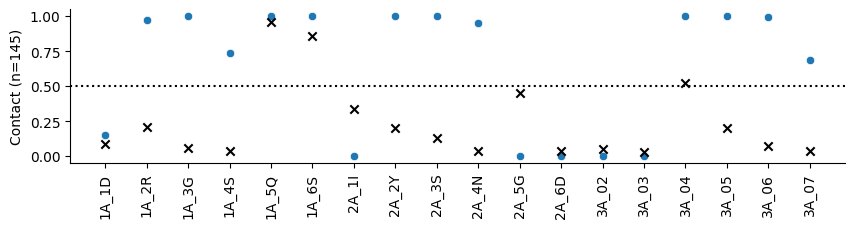

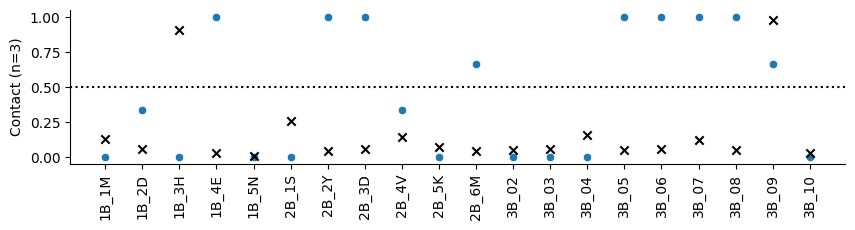

In [87]:
chains = ['A', 'B']

for chain in chains:
    df = pd.read_pickle(f'min_dist_chain{chain}.pkl')

    # convert distances to contacts
    df['contact'] = np.where(df['min_dist'] < 5, 1, 0)

    # fraction of contacts for each resid
    df_mean = df.groupby('resid', as_index=False)['contact'].mean()

    # experimental data
    df_exp = pd.read_csv('YF-AlaScan.csv', sep=';')
    df_exp = df_exp[df_exp['Name'] != 'template']
    df_exp['chain'] = df_exp['Name'].str[4]
    df_exp = df_exp[df_exp['chain'] == chain]

    df_exp['Name_mod'] = np.where(
    df_exp['Name'].str.startswith('CDR3'),
    df_exp['Name'].str[3:6] + df_exp['Name'].str[-2].astype(int).map('{:02d}'.format),
    df_exp['Name'].str[3:6] + df_exp['Name'].str[-2] + df_exp['Name'].str[-3]
    )
    df_exp['resid'] = np.where(df_exp['Name_mod'] == '3B_00', '3B_10', df_exp['Name_mod'])
    df_exp['Results_mod'] = (100 - df_exp['Results']) / 100
    df_exp = df_exp[['resid', 'Results_mod']]
    df_exp.to_pickle(f'YF-AlaScan_chain{chain}.pkl')

    tmp = pd.merge(df_mean, df_exp, on='resid')
    fig, ax = plt.subplots(1,1,figsize=(10,2))
    sns.scatterplot(tmp, x='resid', y='contact', ax=ax, legend=False)
    sns.scatterplot(tmp, x='resid', y='Results_mod', ax=ax, legend=False, color='black', marker='x', linewidth=1.5)

    ax.tick_params(axis='x', rotation=90)
    ax.set_xlabel('')
    ax.set_ylabel(f'Contact (n={len(np.unique(df['tcr_id']))})')
    ax.axhline(0.5, color='black', linestyle=':')
    sns.despine()

# Correlate AlaScan data with plddt

In [82]:
def extract_cdr_plddt(cif_path, cdr_dict, chain_map={"TRA":"TCRA","TRB":"TCRB"}):
    """
    Extract plddt of CDRs based on the respective sequences.
    """

    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("cif", cif_path)
    model = structure[0]

    cdr_plddt = {}

    for chain_label, chain_id in chain_map.items():
        chain_obj = model[chain_id]

        residues = [res for res in chain_obj if res.id[0] == " " and "CA" in res]
        seq = "".join(seq1(res.get_resname()) for res in residues)

        cdr_dict_chain = {}
        for key, value in cdr_dict.items():
            if key.endswith(chain_id[-1]):
                cdr_dict_chain[key] = value

        for cdr, cdr_seq in cdr_dict_chain.items():
            L = len(cdr_seq)

            start_idx = seq.find(cdr_seq)
            if start_idx == -1:
                print(f"Warning: {cdr} not found in {chain_id} of {cif_path}")
                continue

            end_idx = start_idx + L
    
            plddts = []

            for res in residues[start_idx:end_idx]:
                res_plddts = []
                for atom in res.get_atoms():
                    res_plddts.append(atom.get_bfactor())

                plddts.append(np.mean(res_plddts))


            cdr_plddt[cdr] = np.array(plddts)/100

    return cdr_plddt


In [ ]:
topdir = '../260202_YF-modes/data_julien'
batches = {'LAU5013': 'LAU5013/YF_LAU5013_sc_WT', 
           'Public_Data':'Public_Data/YF_public_pairedData_20251010'}

df = pd.read_csv('AF_models_high_conf.csv')

# select alpha-/beta chains with same V-segment and CDR3 length as experimentally tested TCR
dico = {'A' : ['TRAV12-2', 'TRAJ30', 10],
        'B' : ['TRBV28', 'TRBJ2-7', 13]}

for chain, features in dico.items():
    df_chain = df[(df[f'TR{chain}V'] == features[0]) & (df[f'TR{chain}J'] == features[1]) & (df[f'cdr3_TR{chain}'].str.len() == features[2])]

    lst = []
    for idx, row in df_chain.iterrows():
        tcr_id = row['id']
        batch_short = row['batch']

        cif_file = f'{topdir}/{batches[batch_short]}/model/{tcr_id}_model.cif'

        # get residue ids
        cdr_dict = {cdr: str(row[cdr]).upper() for cdr in [f"cdr1_TR{chain}",f"cdr2_TR{chain}",f"cdr3_TR{chain}"]}

        # get plddts
        cdr_plddts = extract_cdr_plddt(cif_file, cdr_dict, chain_map={f"TR{chain}":f"TCR{chain}"})

        res_ids = []
        for cdr, seq in cdr_dict.items():
            for cnt, residue in enumerate(seq):
                tmp = cdr.split('_')
                if cdr.startswith('cdr3'):
                    id = f'{tmp[0][-1]}{tmp[1][-1]}_{cnt+1:02d}'
                else:
                    id = f'{tmp[0][-1]}{tmp[1][-1]}_{cnt+1}{residue}'
                res_ids.append(id)

        results = pd.DataFrame()
        results['resid'] = np.array(res_ids)
        results['plddt'] = np.concatenate(list(cdr_plddts.values()))
        results['tcr_id'] = tcr_id
        lst.append(results)

    results = pd.concat(lst)
    results.to_pickle(f'plddt_chain{chain}.pkl')


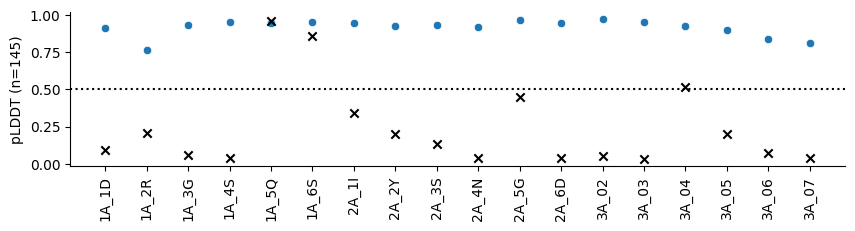

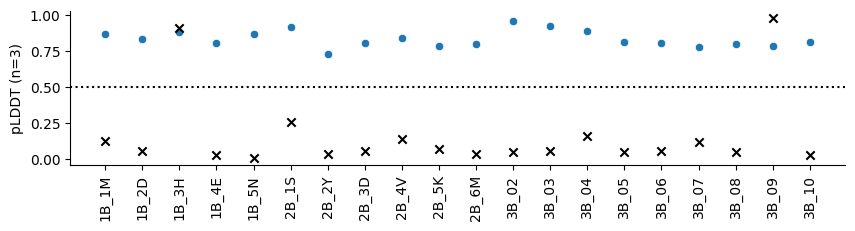

In [88]:
chains = ['A', 'B']

for chain in chains:
    df = pd.read_pickle(f'plddt_chain{chain}.pkl')
    
    df_mean = df.groupby('resid', as_index=False)['plddt'].mean()

    # experimental data
    df_exp = pd.read_pickle(f'YF-AlaScan_chain{chain}.pkl')

    tmp = pd.merge(df_mean, df_exp, on='resid')
    
    fig, ax = plt.subplots(1,1,figsize=(10,2))
    sns.scatterplot(tmp, x='resid', y='plddt', ax=ax, legend=False)
    sns.scatterplot(tmp, x='resid', y='Results_mod', ax=ax, legend=False, color='black', marker='x', linewidth=1.5)

    ax.tick_params(axis='x', rotation=90)
    ax.set_xlabel('')
    ax.set_ylabel(f'pLDDT (n={len(np.unique(df['tcr_id']))})')
    ax.axhline(0.5, color='black', linestyle=':')
    sns.despine()

# Xscan

## Activation scores

In [11]:
# only consider mutant whe AA category is changing
# Define amino acid groups
aa_type_map = {
    'A':'Hydrophobic','V':'Hydrophobic','I':'Hydrophobic','L':'Hydrophobic','M':'Hydrophobic',

    'F':'Aromatic','W':'Aromatic','Y':'Aromatic',

    'D':'Negative','E':'Negative',
    'K':'Positive','R':'Positive','H':'Positive',

    'S':'Polar','T':'Polar','N':'Polar','Q':'Polar',

    'G':'Special','P':'Special', 'C':'Special'
}

# Define amino acid volumes
aa_volume = {
    'G': 60,  'A': 88,  'S': 89,  'C': 108,
    'P': 112, 'T': 116, 'D': 111, 'N': 114,
    'V': 140, 'E': 138, 'Q': 143, 'H': 153,
    'M': 162, 'I': 166, 'L': 166, 'K': 168,
    'R': 173, 'F': 189, 'Y': 193, 'W': 227
}

file = 'TableS10_X-scan_oriDATA.xlsx'

df_epitope = pd.DataFrame()
sequence = 'LLWNGPMAV'
df_epitope['Aa_WT'] = list(sequence)
df_epitope['Position'] = np.arange(len(sequence)) + 1

lst = []
for i in range(3):
    df = pd.read_excel(file, sheet_name=i)
    df['Aa'] = df['Aa'].str[0]
    df['Position'] = df['Position'].str[-1].astype(int)
    
    # annotate WT sequence
    df = pd.merge(df, df_epitope, on='Position')
    
    # annotate aa type
    df['Aa_type'] = df['Aa'].map(aa_type_map)
    df['Aa_WT_type'] = df['Aa_WT'].map(aa_type_map)
    
    # add volume annotation
    df['Vol_mut'] = df['Aa'].map(aa_volume)
    df['Vol_WT'] = df['Aa_WT'].map(aa_volume)
    df['TCR'] = f'TCR_YF{i+1}'

    lst.append(df)

df = pd.concat(lst)
df.to_pickle('activation_scores.pkl')


## SASA

In [ ]:
# normalize SASA to residue size
max_sasa = {
    'A': 121, 'R': 265, 'N': 187, 'D': 187,
    'C': 148, 'Q': 214, 'E': 214, 'G': 97,
    'H': 216, 'I': 195, 'L': 191, 'K': 230,
    'M': 203, 'F': 228, 'P': 154, 'S': 143,
    'T': 163, 'W': 264, 'Y': 255, 'V': 165
}

sequence = 'LLWNGPMAV'
topdir = '../260223_YF-modes_exp_integration/Xscan_models/AF3_outputs'

parser = MMCIFParser(QUIET=True)
results = {'Position':[],
           'SASA':[],
           'rSASA':[],
           'TCR':[]}

for i in range(3):
    file = f'{topdir}/tcr_yf{i+1}/tcr_yf{i+1}_model.cif'
    structure = parser.get_structure('structure', file)
    
    sr = ShrakeRupley()
    sr.compute(structure, level="R")  # R = per residue
    
    for model in structure:
        for chain in model:
            if chain.id == "PEPTIDE":   # change if needed
                for residue in chain:
                    results['Position'].append(residue.id[1])
                    results['SASA'].append(residue.sasa)
                    wt_aa = sequence[residue.id[1] - 1]
                    results['rSASA'].append(residue.sasa / max_sasa[wt_aa])
                    results['TCR'].append(f'TCR_YF{i+1}')

df = pd.DataFrame(results)
df.to_pickle('relative_sasa.pkl')

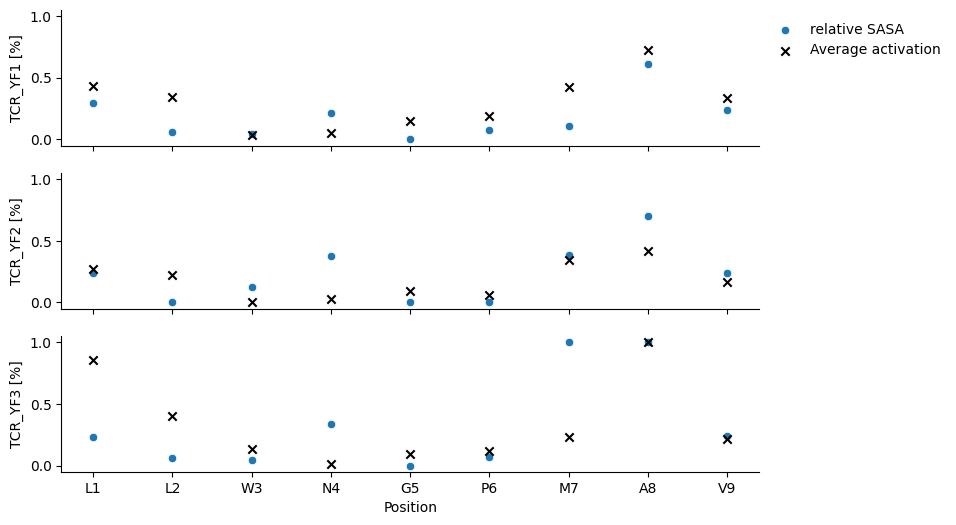

In [14]:
sequence = 'LLWNGPMAV'
df_activation = pd.read_pickle('activation_scores.pkl')[['Position', 'TCR', 'ActivationScore']]
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position', 'TCR'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'] / df_activation['ActivationScore'].max() # scale (maximum to one)
#df_activation.loc[df_activation['ActivationScore'] > 1, 'ActivationScore'] = 1

df_sasa = pd.read_pickle('relative_sasa.pkl')[['Position', 'TCR', 'rSASA']]
df_sasa['rSASA'] = df_sasa['rSASA'] / df_sasa['rSASA'].max() # scale (maximum to one)

df = pd.merge(df_activation, df_sasa, on=['Position', 'TCR'])

fig, axes = plt.subplots(3,1, figsize=(9,6), sharex=True, sharey=True)

for i in range(3):
        ax = axes[i]
        tmp = df[df['TCR'] == f'TCR_YF{i+1}']
        sns.scatterplot(data=tmp, x='Position', y='rSASA', ax=ax, label='relative SASA')
        sns.scatterplot(data=tmp, x='Position', y='ActivationScore', ax=ax, label='Average activation', marker='x', color='black', linewidth=1.5)
        ax.legend([], [], frameon=False)
        ax.set_ylabel(f'TCR_YF{i+1} [%]')



axes[0].legend(bbox_to_anchor=(1,1), frameon=False, title='', loc='upper left')
new_labels = [f'{sequence[i]}{i+1}' for i in range(9)]
axes[2].set_xticks(range(1, len(new_labels)+1))
axes[2].set_xticklabels(new_labels)

sns.despine()


## H-Bonds 

In [18]:
# Simplified donor/acceptor definitions
DONORS = {"N", "ND2", "NE2", "NZ", "NE", "NH1", "NH2"}  # common donor atoms in sidechains/backbone N-H
ACCEPTORS = {"O", "OD1", "OD2", "OE1", "OE2", "OG", "OG1"}  # common acceptors include O and sometimes N

def find_peptide_tcr_hbonds(cif_file,
                            peptide_chain="PEPTIDE",
                            tcr_chains=("TCRA","TCRB"),
                            cutoff=3.5):
    
    parser = MMCIFParser(QUIET=True)
    structure = parser.get_structure("model", cif_file)
    model = structure[0]
    peptide = model[peptide_chain]

    # collect TCR atoms with their donor/acceptor status
    tcr_atoms = []
    tcr_coords = []
    tcr_types = []  # "donor" or "acceptor"

    for chain_id in tcr_chains:
        for atom in model[chain_id].get_atoms():
            if atom.element not in {"N", "O"}:
                continue
            tcr_atoms.append(atom)
            tcr_coords.append(atom.coord)
            if atom.name in DONORS:
                tcr_types.append("donor")
            else:
                tcr_types.append("acceptor")

    tcr_coords = np.array(tcr_coords)
    tree = cKDTree(tcr_coords)

    hbonds = []

    # loop peptide atoms
    for res in peptide:
        for atom in res:
            if atom.element not in {"N", "O"}:
                continue

            # determine if peptide atom is donor or acceptor
            if atom.name in DONORS:
                pep_type = "donor"
            else:
                pep_type = "acceptor"

            coord = atom.coord

            # query nearby TCR atoms
            idxs = tree.query_ball_point(coord, cutoff)

            for idx in idxs:
                t_atom = tcr_atoms[idx]
                t_type = tcr_types[idx]

                # only donor-acceptor pairs
                if pep_type == t_type:
                    continue

                dist = np.linalg.norm(coord - t_atom.coord)

                hbonds.append({
                    "pep_res": res.get_resname(),
                    "pep_pos": res.id[1],
                    "pep_atom": atom.name,
                    "tcr_chain": t_atom.get_parent().get_parent().id,
                    "tcr_res": t_atom.get_parent().get_resname(),
                    "tcr_pos": t_atom.get_parent().id[1],
                    "tcr_atom": t_atom.name,
                    "dist": dist
                })

    return hbonds

In [27]:
sequence = 'LLWNGPMAV'
topdir = '../260223_YF-modes_exp_integration/Xscan_models/AF3_outputs'

results = {'Position':[],
           'hbonds':[],
           'TCR':[]}

for i in range(3):
    file = f'{topdir}/tcr_yf{i+1}/tcr_yf{i+1}_model.cif'

    hbonds = find_peptide_tcr_hbonds(file)

    counts = defaultdict(int)
    for h in hbonds:
        counts[h["pep_pos"]] += 1

    for pos in range(1, len(sequence) + 1):
        if pos in counts:
            results['Position'].append(pos)
            results['hbonds'].append(counts[pos])
            results['TCR'].append(f'TCR_YF{i+1}')
        else:
            results['Position'].append(pos)
            results['hbonds'].append(0)
            results['TCR'].append(f'TCR_YF{i+1}')

df = pd.DataFrame(results)
df.to_pickle('hbonds.pkl')

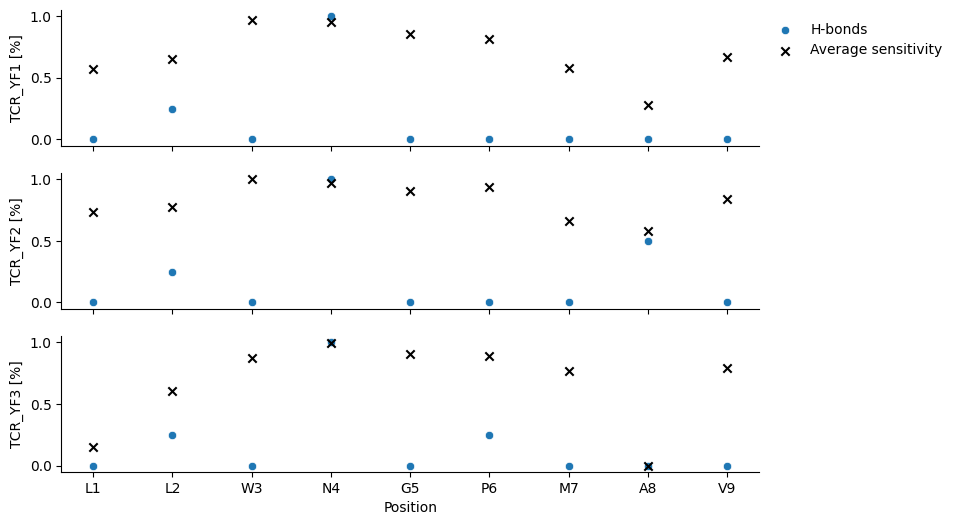

In [ ]:
sequence = 'LLWNGPMAV'
df_activation = pd.read_pickle('activation_scores.pkl')[['Position', 'TCR', 'ActivationScore']]
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df_activation = (df_activation
        .groupby(['Position', 'TCR'], as_index=False)['ActivationScore']
        .mean())
df_activation['ActivationScore'] = df_activation['ActivationScore'] / df_activation['ActivationScore'].max() # scale (maximum to one)
df_activation['SensitivityScore'] = 1 - df_activation['ActivationScore'] 

df_hbonds = pd.read_pickle('hbonds.pkl')[['Position', 'TCR', 'hbonds']]
df_hbonds['hbonds'] = df_hbonds['hbonds'] / df_hbonds['hbonds'].max() # scale (maximum to one)

df = pd.merge(df_activation, df_hbonds, on=['Position', 'TCR'])

fig, axes = plt.subplots(3,1, figsize=(9,6), sharex=True, sharey=True)

for i in range(3):
        ax = axes[i]
        tmp = df[df['TCR'] == f'TCR_YF{i+1}']
        sns.scatterplot(data=tmp, x='Position', y='hbonds', ax=ax, label='H-bonds')
        sns.scatterplot(data=tmp, x='Position', y='SensitivityScore', ax=ax, label='Average sensitivity', marker='x', color='black', linewidth=1.5)
        ax.legend([], [], frameon=False)
        ax.set_ylabel(f'TCR_YF{i+1} [%]')



axes[0].legend(bbox_to_anchor=(1,1), frameon=False, title='', loc='upper left')
new_labels = [f'{sequence[i]}{i+1}' for i in range(9)]
axes[2].set_xticks(range(1, len(new_labels)+1))
axes[2].set_xticklabels(new_labels)

sns.despine()

## Correlation plots

In [ ]:
# sasa
df_sasa = pd.read_pickle('relative_sasa.pkl')

# hbonds
df_hbonds = pd.read_pickle('hbonds.pkl')
df = pd.merge(df_sasa, df_hbonds, on=['TCR', 'Position'])

# activation scores
df_activation = pd.read_pickle('activation_scores.pkl')[['Position', 'TCR', 'ActivationScore']]
df_activation['ActivationScore'] = df_activation['ActivationScore']/100
df = pd.merge(df, df_activation, on=['TCR','Position'])

# normalize for each TCR individually
lst = []
for name, group in df.groupby('TCR'):
    cols_to_norm = ['ActivationScore', 'rSASA', 'hbonds']

    for col in cols_to_norm:
        group[col] = (group[col] - group[col].min()) / (group[col].max() - group[col].min())
    lst.append(group)
df = pd.concat(lst)

# model score -> 1-norm. hbonds for polar residues, norm. relative sasa for rest
sequence = 'LLWNGPMAV'
df['aa'] = df['Position'].astype(int).apply(lambda x: sequence[x-1])

aa_hbond = ['S', 'T', 'Y', 'N', 'Q', 'H', 'D', 'E', 'K', 'R']

df['ModelScore'] = np.where(df['aa'].isin(aa_hbond), 1-df['hbonds'], df['rSASA'])
df.to_pickle('model-score.pkl')

   Position      TCR  ModelScore  ActivationScore
0         1  TCR_YF1    0.478316         0.495798
1         2  TCR_YF1    0.095663         0.399207
2         3  TCR_YF1    0.069211         0.038394
3         4  TCR_YF1    0.000000         0.056374
4         5  TCR_YF1    0.000000         0.168134
5         6  TCR_YF1    0.118647         0.216534
6         7  TCR_YF1    0.177418         0.484383
7         8  TCR_YF1    1.000000         0.827099
8         9  TCR_YF1    0.393004         0.382587
   Position      TCR  ModelScore  ActivationScore
0         1  TCR_YF2    0.335679         0.289593
1         2  TCR_YF2    0.000000         0.242014
2         3  TCR_YF2    0.182144         0.004614
3         4  TCR_YF2    0.000000         0.035090
4         5  TCR_YF2    0.000000         0.104620
5         6  TCR_YF2    0.000000         0.069465
6         7  TCR_YF2    0.548153         0.365335
7         8  TCR_YF2    1.000000         0.449354
8         9  TCR_YF2    0.344759         0.174522


Text(0.5, 0, 'Model score')

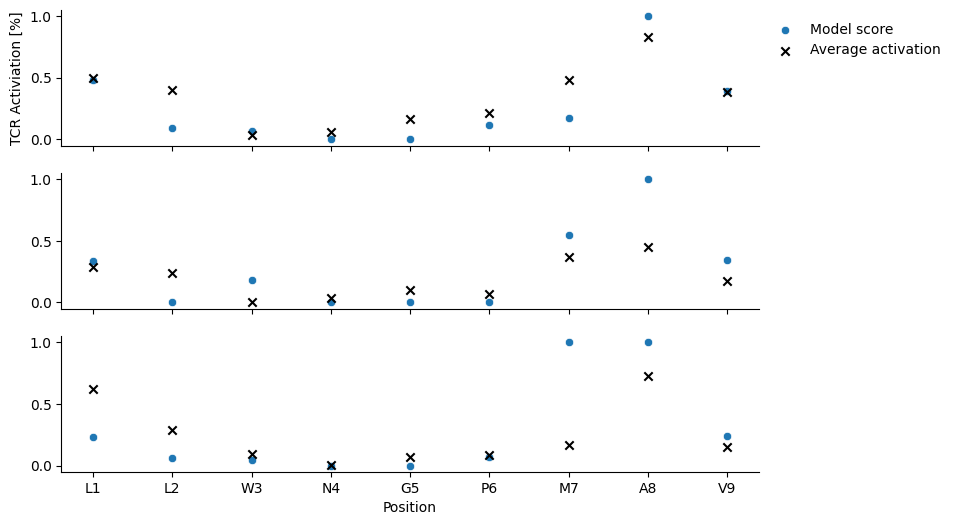

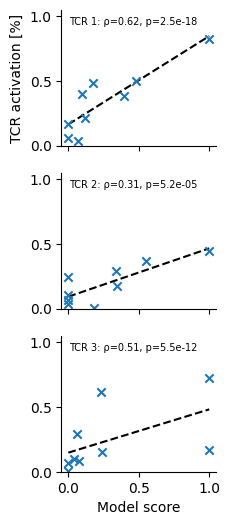

In [107]:
sequence = 'LLWNGPMAV'
df = pd.read_pickle('model-score.pkl')

fig, axes = plt.subplots(3,1, figsize=(9,6), sharex=True, sharey=True)

for i in range(3):
        ax = axes[i]
        tmp = df[df['TCR'] == f'TCR_YF{i+1}']
        tmp = (tmp
        .groupby(['Position', 'TCR', 'ModelScore'], as_index=False)['ActivationScore']
        .mean())
        print(tmp)
        sns.scatterplot(data=tmp, x='Position', y='ModelScore', ax=ax, label='Model score')
        sns.scatterplot(data=tmp, x='Position', y='ActivationScore', ax=ax, label='Average activation', marker='x', color='black', linewidth=1.5)
        ax.legend([], [], frameon=False)
        ax.set_ylabel('')

axes[0].set_ylabel('TCR Activiation [%]')


axes[0].legend(bbox_to_anchor=(1,1), frameon=False, title='', loc='upper left')
new_labels = [f'{sequence[i]}{i+1}' for i in range(9)]
axes[2].set_xticks(range(1, len(new_labels)+1))
axes[2].set_xticklabels(new_labels)

sns.despine()

# correlation plot
fig, axes = plt.subplots(3,1,figsize=(2,6), sharey=True, sharex=True)

for i in range(3):
        ax = axes[i]
        df = pd.read_pickle('model-score.pkl')
        df = df[df['TCR'] == f'TCR_YF{i+1}']

        #sns.scatterplot(df, x='ModelScore', y='ActivationScore', hue='Position', ax=ax, legend=False, s=15)

        # Compute Spearman correlation
        df = df.dropna()
        rho, pval = spearmanr(df['ModelScore'], df['ActivationScore'])
        print(f"ActivationScore: Spearman rho = {rho:.2f}, p = {pval:.3g}")

        # Draw a smooth line showing monotonic trend
        sns.regplot(
        x=df['ModelScore'], 
        y=df['ActivationScore'], 
        ax=ax, 
        scatter=False,       # don't draw points again
        color='black',       # line color
        line_kws={'lw':1.5, 'ls':'--'},
        ci=False
        )

        # Add rho to the plot
        # Format string
        if pval < 0.01:
                p_str = f"{pval:.1e}"   # scientific notation
        else:
                p_str = f"{pval:.2f}"   # fixed-point

        ax.text(
        0.05, 0.95, f"TCR {i+1}: ρ={rho:.2f}, p={p_str}", 
        transform=ax.transAxes, fontsize=7, verticalalignment='top'
        )

        df_avg = (df.groupby(['Position', 'ModelScore'], as_index=False)['ActivationScore'].mean())
        sns.scatterplot(df_avg, x='ModelScore', y='ActivationScore', ax=ax, legend=False, marker='x', linewidth=1.5, zorder=2)

        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_ylim(0,1.05)
        sns.despine()


axes[0].set_ylabel('TCR activation [%]')
axes[2].set_xlabel(f'Model score')
